# Lab: Support Stuff

## Overview
The purpose of this lab is to explore and reinforce some of the concepts related to DSP algorithms as implemented on the Arm Cortex-M4 on the STM32F411E DISCO. This notebook provides some support functionality that complements the main instructions of the lab.

If you need a refresher of some of the code, please check out prior labs on D2L (lab -1)

In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

from thinkdsp import CosSignal, SinSignal, SquareSignal, Wave, read_wave, WavFileWriter
from thinkdsp import decorate
from IPython.display import Audio

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io.wavfile import read
import wave

--2025-04-08 23:02:30--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2025-04-08 23:02:30--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2025-04-08 23:02:31 (3.63 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



# Raw reading

In Lab 1, we will manipulate signals that are stored in memory. To make things a little bit easier, we can use Python to plot/listen to some of the signals. To investigate the signals, you should upload the .wav/.bin/.raw file to the same directory as this notebook.

If we are reading a .wav, we will use scipy's ```read``` function. Otherwise, we will use the built-in file reading capabilities of Python together with numpy.  

In [2]:
ls


__pycache__/  sample_data/  thinkdsp.py


In [7]:
# example, read a binary file into an array of float32
# rawdata = open("a440_32f.bin", "rb").read()
# rawdata = open("a440_16-bit.bin", "rb").read()
# rawdata = open("filtered440_int.bin", "rb").read()
# rawdata = open("processSample_filtered.bin", "rb").read()
# rawdata = open("block16_filtered.bin", "rb").read()
# rawdata = open("unfoldedBlock16_filtered.bin", "rb").read()
rawdata = open("assemblyUnfoldedBlock16_filtered.bin", "rb").read()

data = np.frombuffer(rawdata, dtype=np.int16, count=-1)

We can then plot the acquired data:

In [8]:
type(data[1])
print(data.max() , data.min())

26331 -26337


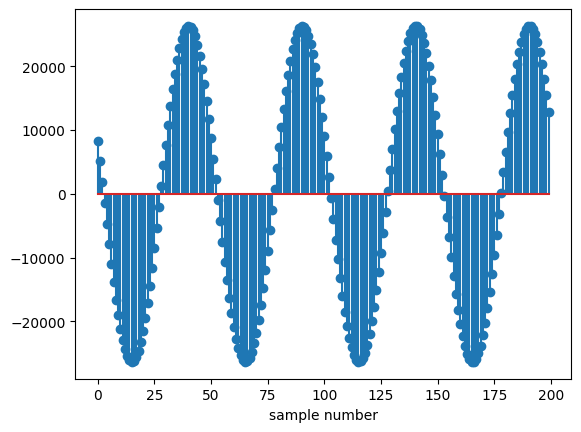

In [9]:
# now let's plot the first 40 samples
no_of_samples_to_plot = 200
plt.stem(range(0,no_of_samples_to_plot), data[1:no_of_samples_to_plot +1])
plt.xlabel("sample number")
plt.show()

We can use ThinkDSP's helpful functions too. Just remember to set the framerate as per the individual file.

In [ ]:
audio = Wave(data, framerate=44100)
audio.make_audio()

In [ ]:
audio.write("filtered440_int.wav")

Writing filtered440_int.wav


# Wav reading
Wav files have some header information, which makes them not as useful to directly read. No problem though, because we'll use scipy's ```read``` function. ```read``` returns two values, the sampling rate (which is stored in the header of the Wav file) and the actual data itself.

Let's start with a wav file that comprises float32 values

In [ ]:
sampling_rate, wavedata = read("a440_32f.wav")
print("Sampling rate is: " + str(sampling_rate) + "kHz")

Sampling rate is: 44100kHz


In [ ]:
wavedata # you should see this as float32

array([    0,  1026,  2048, ..., -3063, -2048, -1026], dtype=int16)

Notice you can listen to what's going on with ThinkDSP's functions

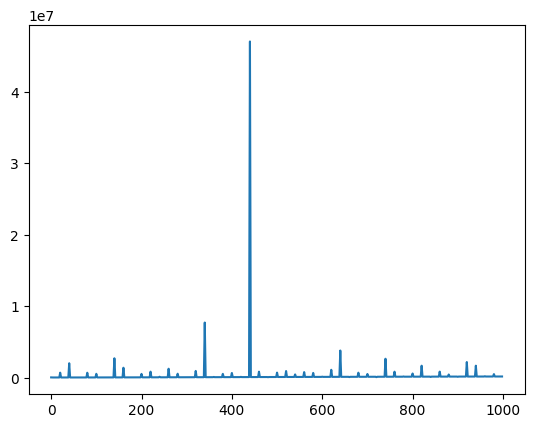

In [ ]:
# spectrum = new_wave.make_spectrum()

spectrum = audio.make_spectrum()
spectrum.plot(high=1000)

There's nothing stopping you from adding/combining signals, **but** you must make sure you are converting between data types correctly.

In [ ]:
c523 = SinSignal(freq=523.251, amp=0.5)
c523_wave = c523.make_wave(duration=0.5, framerate=44100)
c523_wave.ys

array([ 0.        ,  0.0372408 ,  0.07427472, ..., -0.26766055,
       -0.29837248, -0.32742689])

In [ ]:
c523_wave.make_audio()

Check the range of the signal we created. If we're in the range [-1,1) then we can use our usual tricks!

In [ ]:
maximum = max(c523_wave.ys)
minimum = min(c523_wave.ys)
print("max: " + str(maximum) + ", min: " + str(minimum))

max: 0.4999999984704374, min: -0.49999999957907226


In [ ]:
 c523_int16 = (c523_wave.ys * 32768).astype(np.int16)
 c523_int16_wave = Wave(c523_int16, framerate = 44100)
 c523_int16_wave.make_audio()

In [ ]:
mix = c523_int16_wave + new_wave
mix.make_audio()

You can also write the new signal back to a binary file if you want

In [ ]:
mix.ys.astype(np.int16).tofile("mixed.bin")